# Group 3: Statistics Project 
Alessandro Pagan, Greta Dell'Amico, Alice Agazzi, Michela Tomasoni


In [594]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
from statsmodels.tsa.stattools import acf
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [595]:
#loading datasets
cc = pd.read_csv("CreditCard.csv")
az = pd.read_csv("azcabgptca.csv")

## Credit Card dataset: loading, data preparation

- Drop the variables share and expenditure
- Remove unnecessary columns from the credit card dataset and keep only a relevant subset of variables
- Recode the target variable card into a binary numeric variable and create dummy variables for categorical features
- Define the response variable y, add the intercept term to the regressors matrix
- Standardize the rergressors

In [596]:
#explore the dataset
print(cc.shape) 
cc.info()
print(cc["card"].value_counts(dropna=False))
cc.head()


(1319, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   card         1319 non-null   object 
 1   reports      1319 non-null   int64  
 2   age          1319 non-null   float64
 3   income       1319 non-null   float64
 4   share        1319 non-null   float64
 5   expenditure  1319 non-null   float64
 6   owner        1319 non-null   object 
 7   selfemp      1319 non-null   object 
 8   dependents   1319 non-null   int64  
 9   months       1319 non-null   int64  
 10  majorcards   1319 non-null   int64  
 11  active       1319 non-null   int64  
dtypes: float64(4), int64(5), object(3)
memory usage: 123.8+ KB
yes    1023
no      296
Name: card, dtype: int64


,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,yes,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,yes,0,33.25000,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,yes,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,yes,0,30.50000,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,yes,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5


In [597]:
#we study whether to remove share and expenditure
cc[["share", "expenditure", "income"]].select_dtypes(include="number").corr().round(3)

,share,expenditure,income
share,1.000,0.839,-0.054
expenditure,0.839,1.000,0.281
income,-0.054,0.281,1.000


In [598]:
cc.groupby("card")[["expenditure", "share"]].describe().round(3)

expenditure                                                            \
           count     mean     std  min     25%      50%      75%       max   
card                                                                         
no         296.0    0.000    0.00  0.0   0.000    0.000    0.000     0.000   
yes       1023.0  238.602  287.71  0.0  66.517  150.177  313.962  3099.505   

       share                                                
       count   mean    std  min    25%   50%    75%    max  
card                                                        
no     296.0  0.000  0.000  0.0  0.000  0.00  0.001  0.002  
yes   1023.0  0.088  0.099  0.0  0.027  0.06  0.114  0.906

In [599]:
#removing columns
cc_clean = cc.copy()

exclude = {"share", "expenditure"}
cols_cc = [c for c in cc_clean.columns if c not in exclude]
cc_clean = cc_clean[cols_cc].copy()
cc_clean


,card,reports,age,income,owner,selfemp,dependents,months,majorcards,active
0,yes,0,37.66667,4.5200,yes,no,3,54,1,12
1,yes,0,33.25000,2.4200,no,no,3,34,1,13
2,yes,0,33.66667,4.5000,yes,no,4,58,1,5
3,yes,0,30.50000,2.5400,no,no,0,25,1,7
4,yes,0,32.16667,9.7867,yes,no,2,64,1,5
...,...,...,...,...,...,...,...,...,...,...
1314,yes,0,33.58333,4.5660,yes,no,0,94,1,19
1315,no,5,23.91667,3.1920,no,no,3,12,1,5
1316,yes,0,40.58333,4.6000,yes,no,2,1,1,2
1317,yes,0,32.83333,3.7000,no,yes,0,60,1,7


In [600]:
#handling dummies
cc_clean["card"] = np.where(cc_clean["card"] == "yes", 1, 0)
x_cc = cc_clean.drop(columns=["card"]).copy()
x_cc = pd.get_dummies(x_cc, columns=["owner", "selfemp"], drop_first=True)
cc_clean

,card,reports,age,income,owner,selfemp,dependents,months,majorcards,active
0,1,0,37.66667,4.5200,yes,no,3,54,1,12
1,1,0,33.25000,2.4200,no,no,3,34,1,13
2,1,0,33.66667,4.5000,yes,no,4,58,1,5
3,1,0,30.50000,2.5400,no,no,0,25,1,7
4,1,0,32.16667,9.7867,yes,no,2,64,1,5
...,...,...,...,...,...,...,...,...,...,...
1314,1,0,33.58333,4.5660,yes,no,0,94,1,19
1315,0,5,23.91667,3.1920,no,no,3,12,1,5
1316,1,0,40.58333,4.6000,yes,no,2,1,1,2
1317,1,0,32.83333,3.7000,no,yes,0,60,1,7


In [601]:
#add intercept
y_cc = cc_clean["card"].to_numpy(dtype=int)
X_cc = np.column_stack([np.ones(len(x_cc)), x_cc.to_numpy(dtype=float)])
X_cc_cols = ["intercept"] + list(x_cc.columns)
print("X shape:", X_cc.shape, "y shape:", y_cc.shape)
x_cc


X shape: (1319, 10) y shape: (1319,)


,reports,age,income,dependents,months,majorcards,active,owner_yes,selfemp_yes
0,0,37.66667,4.5200,3,54,1,12,1,0
1,0,33.25000,2.4200,3,34,1,13,0,0
2,0,33.66667,4.5000,4,58,1,5,1,0
3,0,30.50000,2.5400,0,25,1,7,0,0
4,0,32.16667,9.7867,2,64,1,5,1,0
...,...,...,...,...,...,...,...,...,...
1314,0,33.58333,4.5660,0,94,1,19,1,0
1315,5,23.91667,3.1920,3,12,1,5,0,0
1316,0,40.58333,4.6000,2,1,1,2,1,0
1317,0,32.83333,3.7000,0,60,1,7,0,1


In [602]:
#variables standardization
X_cc_std = X_cc.copy()
mu_cc = X_cc_std[:, 1:].mean(axis=0)
sd_cc = X_cc_std[:, 1:].std(axis=0)
sd_cc[sd_cc == 0] = 1.0
X_cc_std[:, 1:] = (X_cc_std[:, 1:] - mu_cc) / sd_cc

print(X_cc_std.shape, y_cc.shape)


(1319, 10) (1319,)


## Azcabgptca dataset: loading, data preparation

- Define the variable of interest
- Add the intercept
- Standardize regressors

In [603]:
az_clean = az.copy()
az_clean

y_az = az_clean["los"].to_numpy()
x_az = az_clean.drop(columns=["los"])

X_az = np.column_stack([np.ones(len(x_az)), x_az.to_numpy()])
X_az_cols = ["intercept"] + list(x_az.columns)

az_clean

,died,procedure,age,gender,los,type
0,0,1,73,0,51,0
1,0,0,67,0,30,1
2,0,1,69,0,43,0
3,0,1,65,0,32,0
4,0,1,79,0,42,1
...,...,...,...,...,...,...
1954,0,1,77,0,6,1
1955,0,1,77,0,5,0
1956,0,1,78,0,5,0
1957,1,1,73,0,1,0


In [604]:
X_az_std = X_az.copy() #standardization

mu_az = X_az_std[:, 1:].mean(axis=0)
sd_az = X_az_std[:, 1:].std(axis=0)
sd_az[sd_az == 0] = 1.0

X_az_std[:, 1:] = (X_az_std[:, 1:] - mu_az) / sd_az

print(X_az_std.shape, y_az.shape)

(1959, 6) (1959,)


# 1a. Fisher Scoring Algorithm (Logit)

- Estimate a Logistic regression model using the Fisher Scoring algorithm:
  X = covariates (n x p), Y = dependent variable (n x 1), epsilon = threshold for convergence
- Run the algorithm
- Coefficients table

In [605]:
def sigmoid(eta):
        return 1.0 / (1.0 + np.exp(-eta))
    
def logit_fisher_scoring(X, Y, epsilon):

    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float).reshape(-1, 1)
    n, p = X.shape

    b_0 = np.zeros((p, 1))
    eta = X @ b_0
    mu = sigmoid(eta)
    w = (mu * (1.0 - mu)).reshape(-1)
    W = np.diag(w)
    Z = eta + (Y - mu) / w.reshape(-1, 1)

    convergence = False
    while not convergence:
        b = np.linalg.solve(X.T @ W @ X, X.T @ W @ Z)

        eta = X @ b
        mu = sigmoid(eta)
        w = (mu * (1.0 - mu)).reshape(-1)
        W = np.diag(w)
        Z = eta + (Y - mu) / w.reshape(-1, 1)

        rel_change = np.sqrt(np.sum((b - b_0) ** 2)) / (np.sqrt(np.sum(b_0 ** 2)) + epsilon)
        if rel_change < epsilon:
            convergence = True

        b_0 = b

    return b



In [606]:
X = X_cc_std #standardized
y = y_cc


In [607]:
beta_hat_logistic = logit_fisher_scoring(X, y, epsilon=1e-8)
beta_hat_logistic

array([[ 1.45821706],
       [-2.35557606],
       [-0.12688172],
       [ 0.3831759 ],
       [-0.302223  ],
       [ 0.03382417],
       [ 0.19528146],
       [ 0.83391406],
       [ 0.23743607],
       [-0.19194106]])

In [608]:
beta_1d = np.asarray(beta_hat_logistic).ravel()
names = ["(Intercept)"] + list(x_cc.columns)

coef_table = pd.DataFrame({
    "term": names,
    "beta_hat": beta_1d,
    "odds_ratio": np.exp(beta_1d)})
coef_table

,term,beta_hat,odds_ratio
0,(Intercept),1.458217,4.298289
1,reports,-2.355576,0.094839
2,age,-0.126882,0.880838
3,income,0.383176,1.466936
4,dependents,-0.302223,0.739173
5,months,0.033824,1.034403
6,majorcards,0.195281,1.215653
7,active,0.833914,2.302313
8,owner_yes,0.237436,1.267994
9,selfemp_yes,-0.191941,0.825356


# 1b. Fisher Scoring (Poisson)

- Estimate a Poisson regression model using the Fisher Scoring algorithm:
  X = covariates (n x p), Y = dependent variable (n x 1), epsilon = threshold for convergence
- Run the algorithm
- Coefficients table

In [609]:
def poisson_log(X, Y, epsilon):

    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float).reshape(-1, 1)
    n, p = X.shape

    b_0 = np.zeros((p, 1))
    eta = X @ b_0
    mu = np.exp(eta)
    w = mu.reshape(-1)
    W = np.diag(w)
    Z = eta + (Y - mu) / mu

    convergence = False
    while not convergence:
        b = np.linalg.solve(X.T @ W @ X, X.T @ W @ Z)

        eta = X @ b
        mu = np.exp(eta)
        w = mu.reshape(-1)
        W = np.diag(w)
        Z = eta + (Y - mu) / mu

        rel_change = np.sqrt(np.sum((b - b_0) ** 2)) / (np.sqrt(np.sum(b_0 ** 2)) + epsilon)
        if rel_change < epsilon:
            convergence = True

        b_0 = b

    return b

In [610]:
X = X_az_std  #standardized
y = y_az

beta_hat_poisson = poisson_log(X, y, epsilon=1e-8)
beta_hat_poisson

array([[ 1.83100746],
       [-0.04124666],
       [ 0.56431504],
       [ 0.04319762],
       [-0.04893933],
       [ 0.09433817]])

In [611]:
names = ["(Intercept)"] + list(x_az.columns)

beta_hat_poisson = np.asarray(beta_hat_poisson).ravel()
coef_table = pd.DataFrame({
    "term": names,
    "beta_hat": beta_hat_poisson,
    "IRR": np.exp(beta_hat_poisson)})

coef_table

,term,beta_hat,IRR
0,(Intercept),1.831007,6.240170
1,died,-0.041247,0.959592
2,procedure,0.564315,1.758243
3,age,0.043198,1.044144
4,gender,-0.048939,0.952239
5,type,0.094338,1.098931


# 2a. Metropolis-Hastings (Logistics)

## First Version: using simple and intuitive assumptions

Metropolis Hastings with: 
- Normal prior centered in zero 
- Normal proposal distribution with isotropic covariance
- Starting point of MH at Beta = [0,...,0]

Main points
- Define the Logistic likelihood, prior distribution and posterior distribution
- Metropolis–Hastings: starting point Beta = [0,...,0] and proposal distribution with isotropic (sigma) variance
- Tuning of parameters
- Run and assess

In [612]:
y = y_cc
X = X_cc_std

In [613]:
tau = 5
#we choose a normal distribution centered in beta with variance tau (tau big enough)
def log_prior(beta, tau):
    return -0.5 * np.sum((beta / tau) ** 2)

In [614]:
def log_likelihood_logistic(beta, y, X):
    eta = X @ beta
    p = 1 / (1 + np.exp(-eta))
    return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

In [615]:
def log_posterior(beta, y, X, tau): 
    return log_likelihood_logistic(beta, y, X) + log_prior(beta, tau)

In [616]:
#proposal function with isotropic variance
def propose_beta(beta, sigma, rng):
    return beta + sigma * rng.standard_normal(beta.size)

In [617]:
p = X.shape[1]
beta0 = np.zeros(p) #starting point

In [618]:
def metropolis_hastings(beta0, T, sigma, rng):
    chain = np.zeros((T + 1, beta0.size))
    chain[0] = beta0

    beta_t = beta0.copy()
    log_post_t = log_posterior(beta_t, y, X, tau) 
    accept = 0

    for t in range(T):
        beta_star = propose_beta(beta_t, sigma, rng)
        u = rng.random()

        log_post_star = log_posterior(beta_star, y, X, tau)
        log_alpha = log_post_star - log_post_t

        if np.log(u) <= min(0.0, log_alpha):
            beta_t = beta_star
            log_post_t = log_post_star
            accept += 1

        chain[t + 1] = beta_t
    accept_rate = accept / T
    return chain, accept_rate

Now we look for suitable values of sigma, the number of iterations (T) and the burn in: 
- Different values of sigma (keeping T and the burn in fixed), and a value is selected based on the acceptance rate and ACF(10)
- The number of iterations T is increased until posterior summaries (means and credible intervals) remain stable
-  The burn-in period is chosen based on the stability of posterior summaries

In [619]:
#choosing the right sigma: I try different sigmas and look for a good balance of ACF(10) and acceptance rate
sigmas = [0.05, 0.07, 0.10, 0.13] #proposal sigmas
T_test = 15000 #fixed
burn_frac = 0.30 #fixed

j_income = X_cc_cols.index("income") 

for s in sigmas:
    rng = np.random.default_rng(10)
    ch, acc = metropolis_hastings(beta0, T_test, s, rng)

    burn = int(burn_frac * (ch.shape[0] - 1))
    x = ch[burn:, j_income]

    r = acf(x, nlags=10, fft=True)
    print(f"sigma={s:0.2f} | acc={acc:0.3f} | ACF(10)={r[10]:0.3f}")

#0.07 is the best sigma among the sigmas

sigma=0.05 | acc=0.382 | ACF(10)=0.705
sigma=0.07 | acc=0.239 | ACF(10)=0.676
sigma=0.10 | acc=0.107 | ACF(10)=0.721
sigma=0.13 | acc=0.048 | ACF(10)=0.798


In [620]:
#choosing the right T
T_list = [10000, 20000, 30000] # three possible values of T 
sigma = 0.07 #same as before
burn_frac = 0.30 #fixed
j_income = X_cc_cols.index("income")

for T in T_list:
    rng = np.random.default_rng(123)
    ch, acc = metropolis_hastings(beta0, T, sigma, rng)

    burn = int(burn_frac * (ch.shape[0] - 1))
    x = ch[burn:, j_income]

    m = np.mean(x)
    lo, hi = np.quantile(x, [0.025, 0.975])

    print(f"T={T:>6} | acc={acc:0.3f} | mean={m:.4f} | 95% CI=({lo:.4f},{hi:.4f})")
#the variation is stable: we choose 20000


T= 10000 | acc=0.227 | mean=0.3900 | 95% CI=(0.2119,0.5862)
T= 20000 | acc=0.224 | mean=0.3929 | 95% CI=(0.1919,0.6282)
T= 30000 | acc=0.225 | mean=0.3951 | 95% CI=(0.1808,0.6282)


In [621]:
#choosing the right burn in
burns = [0.10, 0.20, 0.30, 0.4]
j_income = X_cc_cols.index("income")

rng = np.random.default_rng()
T = 20000
sigma = 0.07
chain_cc, acc_rate_cc = metropolis_hastings(beta0, T, sigma, rng)

for bf in burns:
    burn = int(bf * (chain_cc.shape[0] - 1))
    x = chain_cc[burn:, j_income]
    m = np.mean(x)
    lo, hi = np.quantile(x, [0.025, 0.975])
    print(f"burn_frac={bf:0.2f} | mean={m:0.4f} | 95% CI=({lo:0.4f},{hi:0.4f}) | N={len(x)}")

#we choose a burn in of 30%, to stabilize the chain and have enough observations

burn_frac=0.10 | mean=0.3941 | 95% CI=(0.1891,0.6178) | N=18001
burn_frac=0.20 | mean=0.3960 | 95% CI=(0.1869,0.6188) | N=16001
burn_frac=0.30 | mean=0.3941 | 95% CI=(0.1879,0.6143) | N=14001
burn_frac=0.40 | mean=0.3967 | 95% CI=(0.1922,0.6246) | N=12001


Acceptance rate: 0.2318
Bayesian posterior summaries
   intercept | mean= 1.4764 | sd= 0.0907 | 95% CI=( 1.3014,  1.6605)
     reports | mean=-2.4041 | sd= 0.1775 | 95% CI=(-2.7624, -2.0519)
         age | mean=-0.1261 | sd= 0.0947 | 95% CI=(-0.3094,  0.0581)
      income | mean= 0.3896 | sd= 0.1079 | 95% CI=( 0.1819,  0.6078)
  dependents | mean=-0.3115 | sd= 0.0875 | 95% CI=(-0.4787, -0.1385)
      months | mean= 0.0310 | sd= 0.0923 | 95% CI=(-0.1476,  0.2117)
  majorcards | mean= 0.1944 | sd= 0.0744 | 95% CI=( 0.0429,  0.3397)
      active | mean= 0.8561 | sd= 0.1126 | 95% CI=( 0.6303,  1.0649)
   owner_yes | mean= 0.2491 | sd= 0.0946 | 95% CI=( 0.0608,  0.4373)
 selfemp_yes | mean=-0.1922 | sd= 0.0742 | 95% CI=(-0.3282, -0.0434)


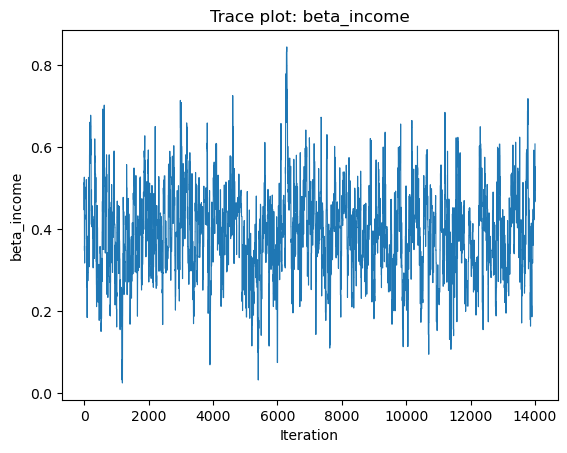

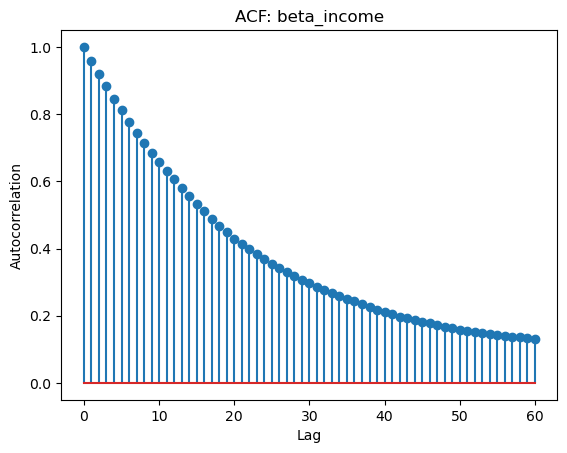

In [622]:
rng = np.random.default_rng(26)
T = 20000
sigma = 0.07
chain_cc, acc_rate_cc = metropolis_hastings(beta0, T, sigma, rng)

print("Acceptance rate:", acc_rate_cc)

burn_frac = 0.30
nlags = 60
burn = int(burn_frac * (chain_cc.shape[0] - 1))
samples = chain_cc[burn:, :]

print("Bayesian posterior summaries")
for j, name in enumerate(X_cc_cols):
    beta_j = samples[:, j]
    mean = np.mean(beta_j)
    sd   = np.std(beta_j)
    lo, hi = np.quantile(beta_j, [0.025, 0.975])
    print(f"{name:>12s} | mean={mean: .4f} | sd={sd: .4f} | 95% CI=({lo: .4f}, {hi: .4f})")

income_samples = samples[:, j_income]

plt.figure()
plt.plot(income_samples, linewidth=0.8)
plt.title("Trace plot: beta_income")
plt.xlabel("Iteration")
plt.ylabel("beta_income")
plt.show()

nlags = 60
r = acf(income_samples, nlags=nlags, fft=True)
plt.figure()
plt.stem(range(nlags + 1), r)
plt.title("ACF: beta_income")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

## Second Version: using results from the frequentist approach

Metropolis Hastings with: 
- Normal prior centered in zero
- Normal proposal distribution with fisher informed variance
- Starting point of MH at MLE for Beta

Main points
- Define the Logistic likelihood, prior distribution and posterior distribution
- Metropolis–Hastings: starting point MLE and proposal distribution with Fisher-Informed variance
- Tuning of parameters
- Run and assess

In [623]:
y = y_cc
X = X_cc_std

In [624]:
#new starting point: MLE from Fisher scoring
beta_mle = np.asarray(beta_hat_logistic).ravel()      
p = X.shape[1]

In [625]:
def log_posterior(beta, y, X, tau): 
    return log_likelihood_logistic(beta, y, X) + log_prior(beta, tau)

In [626]:
#fisher informed variance
eta_mle = X @ beta_mle
p_mle = 1.0 / (1.0 + np.exp(-eta_mle))
w = p_mle * (1.0 - p_mle)

I_mle = (X.T * w) @ X

ridge = 1e-6
V_base = np.linalg.inv(I_mle + ridge * np.eye(p))

In [627]:
def mh_fisher_informed(beta0, T, scale, rng, y, X, tau, V_base):
    chain = np.zeros((T + 1, beta0.size))
    chain[0] = beta0

    L = np.linalg.cholesky(scale * V_base)

    beta_t = beta0.copy()
    logpost_t = log_posterior(beta_t, y, X, tau)
    accept = 0

    for t in range(T):
        beta_star = beta_t + L @ rng.standard_normal(beta_t.size)
        logpost_star = log_posterior(beta_star, y, X, tau)

        log_alpha = logpost_star - logpost_t
        if np.log(rng.random()) < min(0.0, log_alpha):
            beta_t = beta_star
            logpost_t = logpost_star
            accept += 1

        chain[t + 1] = beta_t

    return chain, accept / T

We test different values of scale (keeping T and the burn in fixed), and a value is selected based on the acceptance rate and ACF(10)

In [628]:
#choosing the right scale: I try different scales and look for a good balance of ACF(10) and acceptance rate: scale controls the step size of the rdm walk 
scales = [0.2, 0.5, 1.0, 2.0, 4.0]
T_test = 8000
burn_frac = 0.30

colnames = ["(Intercept)"] + list(x_cc.columns)
j_income = colnames.index("income")

for s in scales:
    rng = np.random.default_rng(10)
    ch, acc = mh_fisher_informed(beta_mle, T_test, s, rng, y, X, tau, V_base)

    burn = int(burn_frac * (ch.shape[0] - 1))
    x = ch[burn:, j_income]

    r = acf(x, nlags=10, fft=True)
    print(f"scale={s:0.2f} | acc={acc:0.3f} | ACF(10)={r[10]:0.3f}")

#0.5 is the best scale among the scales

scale=0.20 | acc=0.504 | ACF(10)=0.599
scale=0.50 | acc=0.289 | ACF(10)=0.504
scale=1.00 | acc=0.146 | ACF(10)=0.496
scale=2.00 | acc=0.049 | ACF(10)=0.701
scale=4.00 | acc=0.012 | ACF(10)=0.875


Acceptance rate (Second version): 0.2901

Bayesian posterior summaries (Second version)
 (Intercept) | mean= 1.4779 | sd= 0.0942 | 95% CI=( 1.2939,  1.6622)
     reports | mean=-2.3959 | sd= 0.1837 | 95% CI=(-2.7807, -2.0551)
         age | mean=-0.1222 | sd= 0.0961 | 95% CI=(-0.3091,  0.0707)
      income | mean= 0.3885 | sd= 0.1065 | 95% CI=( 0.1933,  0.6098)
  dependents | mean=-0.2989 | sd= 0.0883 | 95% CI=(-0.4719, -0.1286)
      months | mean= 0.0406 | sd= 0.0916 | 95% CI=(-0.1350,  0.2242)
  majorcards | mean= 0.2004 | sd= 0.0743 | 95% CI=( 0.0577,  0.3501)
      active | mean= 0.8478 | sd= 0.1161 | 95% CI=( 0.6314,  1.0826)
   owner_yes | mean= 0.2312 | sd= 0.1011 | 95% CI=( 0.0335,  0.4396)
 selfemp_yes | mean=-0.1852 | sd= 0.0725 | 95% CI=(-0.3283, -0.0421)


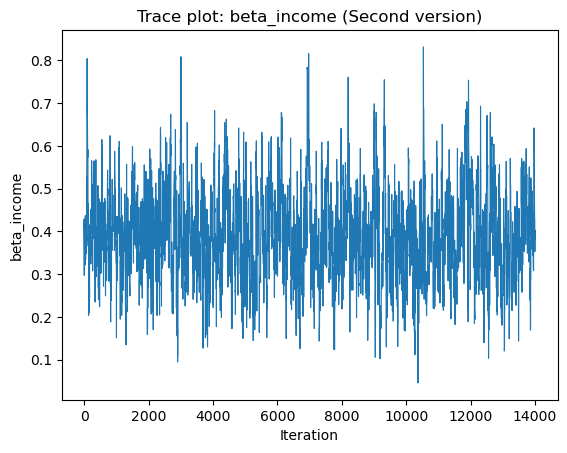

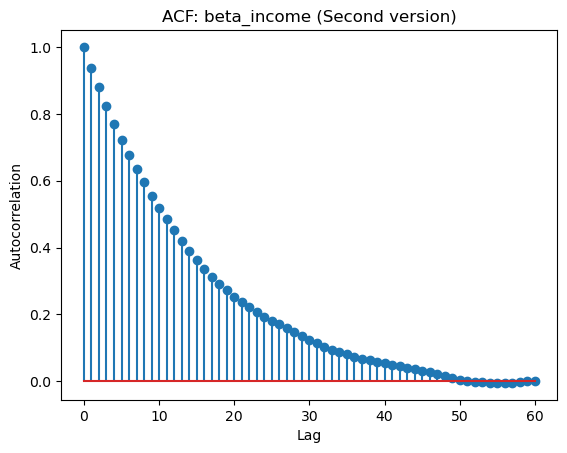

In [629]:
rng = np.random.default_rng(15)
T = 20000
scale = 0.5
chain_cc2, acc_rate_cc2 = mh_fisher_informed(beta_mle, T, scale, rng, y, X, tau, V_base)
print("Acceptance rate (Second version):", acc_rate_cc2)

burn = int(0.30 * T)
samples = chain_cc2[burn::, :]

print("\nBayesian posterior summaries (Second version)")
for j, name in enumerate(colnames):
    b = samples[:, j]
    mean = np.mean(b)
    sd = np.std(b)
    lo, hi = np.quantile(b, [0.025, 0.975])
    print(f"{name:>12s} | mean={mean: .4f} | sd={sd: .4f} | 95% CI=({lo: .4f}, {hi: .4f})")

income_samples = samples[:, j_income]

plt.figure()
plt.plot(income_samples, linewidth=0.8)
plt.title("Trace plot: beta_income (Second version)")
plt.xlabel("Iteration")
plt.ylabel("beta_income")
plt.show()

nlags = 60
r = acf(income_samples, nlags=nlags, fft=True)
plt.figure()
plt.stem(range(nlags + 1), r)
plt.title("ACF: beta_income (Second version)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()


# 2b. Metropolis-Hastings for Azcabgptca

## First Version: using simple and intuitive assumptions

Metropolis Hastings with: 
- Normal prior centered in zero 
- Normal proposal distribution with isotropic covariance
- Starting point of MH at Beta = [0,...,0]

Main points
- Define the Poisson likelihood, prior distribution and posterior distribution
- Metropolis–Hastings: starting point Beta = [0,...,0] and proposal distribution with isotropic (sigma) variance
- Tuning of parameters
- Run and assess

In [630]:
y = y_az
X = X_az_std

In [631]:
tau = 5
def log_prior(beta, tau):
    return -0.5 * np.sum((beta / tau) ** 2)

In [632]:
def log_likelihood_poisson(beta, y, X):
    eta = X @ beta
    lam = np.exp(eta)
    return np.sum(y * np.log(lam) - lam)

In [633]:
def log_posterior(beta,y, X, tau ):
    return log_likelihood_poisson(beta, y, X) + log_prior(beta, tau)

In [634]:
def propose_beta(beta, sigma, rng):
    return beta + sigma * rng.standard_normal(beta.size)

In [635]:
p = X.shape[1]
beta0 = np.zeros(p)

In [636]:
def metropolis_hastings(beta0, T, sigma, rng):
    chain = np.zeros((T + 1, beta0.size))
    chain[0] = beta0

    beta_t = beta0.copy()
    log_post_t = log_posterior(beta_t, y, X, tau)
    accept = 0

    for t in range(T):
        beta_star = propose_beta(beta_t, sigma, rng)
        u = rng.random()

        log_post_star = log_posterior(beta_star, y, X, tau)
        log_alpha = log_post_star - log_post_t

        if np.log(u) <= min(0.0, log_alpha):
            beta_t = beta_star
            log_post_t = log_post_star
            accept += 1

        chain[t + 1] = beta_t

    accept_rate = accept / T
    return chain, accept_rate


Now we look for suitable values of sigma, the number of iterations (T) and the burn in: 
- Different values of sigma (keeping T and the burn in fixed), and a value is selected based on the acceptance rate and ACF(10)
- The number of iterations T is increased until posterior summaries (means and credible intervals) remain stable
-  The burn-in period is chosen based on the stability of posterior summaries

In [637]:
#choosing the right sigma: I try different sigmas and look for a good balance of ACF(10) and acceptance rate
sigmas = [0.01, 0.02, 0.05, 0.1, 0.2]
T_test = 15000
burn_frac = 0.30

j_los = X_az_cols.index("procedure")
for s in sigmas:
    rng = np.random.default_rng(10)
    ch, acc = metropolis_hastings(beta0, T_test, s, rng)

    burn = int(burn_frac * (ch.shape[0] - 1))
    x = ch[burn:, j_los]

    r = acf(x, nlags=10, fft=True)
    print(f"sigma={s:} | acc={acc:0.3f} | ACF(10)={r[10]:0.3f}")

#0.01 is the best sigma among the sigmas

sigma=0.01 | acc=0.201 | ACF(10)=0.501
sigma=0.02 | acc=0.038 | ACF(10)=0.805
sigma=0.05 | acc=0.004 | ACF(10)=0.988
sigma=0.1 | acc=0.003 | ACF(10)=0.988
sigma=0.2 | acc=0.002 | ACF(10)=0.988


In [638]:
#choosing the right T
T_list = [10000, 20000, 30000]
sigma = 0.01 #sigma obtained before
burn_frac = 0.30 #fixed
j_los = X_az_cols.index("procedure")
for T in T_list:
    rng = np.random.default_rng(123)
    ch, acc = metropolis_hastings(beta0, T, sigma, rng)

    burn = int(burn_frac * (ch.shape[0] - 1))
    x = ch[burn:, j_los]

    m = np.mean(x)
    lo, hi = np.quantile(x, [0.025, 0.975])

    print(f"T={T:>6} | acc={acc:0.3f} | mean={m:.4f} | 95% CI=({lo:.4f},{hi:.4f})")

#the variation is stable: we choose 20000

T= 10000 | acc=0.213 | mean=0.5645 | 95% CI=(0.5463,0.5832)
T= 20000 | acc=0.200 | mean=0.5638 | 95% CI=(0.5458,0.5818)
T= 30000 | acc=0.197 | mean=0.5641 | 95% CI=(0.5458,0.5825)


In [639]:
burns = [0.10, 0.20, 0.30, 0.4]
j_los = X_az_cols.index("procedure")

rng = np.random.default_rng()
T = 20000
sigma = 0.01
chain_az, acc_rate_az = metropolis_hastings(beta0, T, sigma, rng)

for bf in burns:
    burn = int(bf * (chain_az.shape[0] - 1))
    x = chain_az[burn:, j_los]

    m = np.mean(x)
    lo, hi = np.quantile(x, [0.025, 0.975])

    print(f"burn_frac={bf:0.2f} | mean={m:.4f} | 95% CI=({lo:.4f},{hi:.4f}) | N={len(x)}")

#we choose a burn in of 30%, to stabilize the chain and have enough observations

burn_frac=0.10 | mean=0.5641 | 95% CI=(0.5454,0.5824) | N=18001
burn_frac=0.20 | mean=0.5641 | 95% CI=(0.5451,0.5825) | N=16001
burn_frac=0.30 | mean=0.5641 | 95% CI=(0.5451,0.5824) | N=14001
burn_frac=0.40 | mean=0.5642 | 95% CI=(0.5451,0.5820) | N=12001


Acceptance rate: 0.20415
Bayesian posterior summaries
   intercept | mean= 1.8303 | sd= 0.0101 | 95% CI=( 1.8113,  1.8512)
        died | mean=-0.0417 | sd= 0.0081 | 95% CI=(-0.0580, -0.0267)
   procedure | mean= 0.5646 | sd= 0.0094 | 95% CI=( 0.5464,  0.5831)
         age | mean= 0.0432 | sd= 0.0084 | 95% CI=( 0.0271,  0.0604)
      gender | mean=-0.0487 | sd= 0.0085 | 95% CI=(-0.0652, -0.0329)
        type | mean= 0.0945 | sd= 0.0082 | 95% CI=( 0.0778,  0.1104)


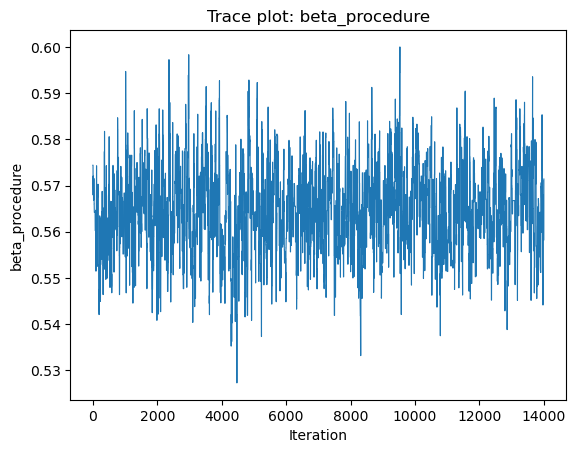

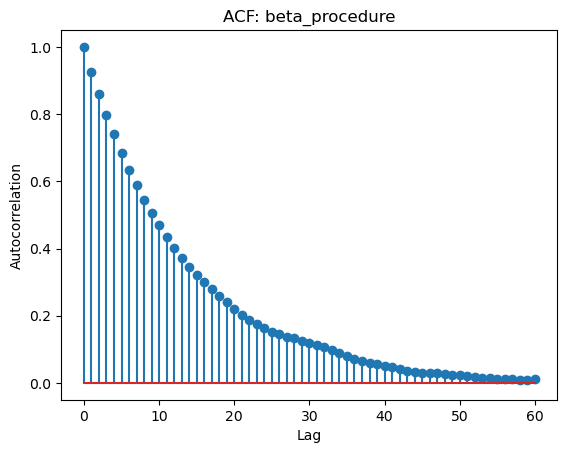

In [640]:
rng = np.random.default_rng(26)
T = 20000
sigma = 0.01
chain_az, acc_rate_az = metropolis_hastings(beta0, T, sigma, rng)

print("Acceptance rate:", acc_rate_az)

burn_frac = 0.30
nlags = 60
burn = int(burn_frac * (chain_az.shape[0] - 1))
samples = chain_az[burn:, :]

print("Bayesian posterior summaries")
for j, name in enumerate(X_az_cols):
    beta_j = samples[:, j]
    mean = np.mean(beta_j)
    sd   = np.std(beta_j)
    lo, hi = np.quantile(beta_j, [0.025, 0.975])
    print(f"{name:>12s} | mean={mean: .4f} | sd={sd: .4f} | 95% CI=({lo: .4f}, {hi: .4f})")

j_proc = X_az_cols.index("procedure")
proc_chain = samples[:, j_proc]

plt.figure()
plt.plot(proc_chain, linewidth=0.8)
plt.title("Trace plot: beta_procedure")
plt.xlabel("Iteration")
plt.ylabel("beta_procedure")
plt.show()


r = acf(proc_chain, nlags=nlags, fft=True)

plt.figure()
plt.stem(range(nlags + 1), r)
plt.title("ACF: beta_procedure")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()


## Second Version: using results from the frequentist approach

Metropolis Hastings with: 
- Normal prior centered in zero
- Normal proposal distribution with fisher informed variance
- Starting point of MH at MLE for Beta

Main points
- Define the Poisson likelihood, prior distribution and posterior distribution
- Metropolis–Hastings: starting point MLE and proposal distribution with Fisher-Informed variance
- Tuning of parameters
- Run and assess

In [641]:
y = y_az
X = X_az_std

In [642]:
beta_mle_p = np.asarray(beta_hat_poisson).ravel() 

In [643]:
def log_posterior(beta, y, X, tau): 
    return log_likelihood_poisson(beta, y, X) + log_prior(beta, tau)

In [644]:
#define the fisher-informed variance
p = X.shape[1]
eta_mle = X @ beta_mle_p

mu_mle=np.exp(eta_mle)
w=mu_mle

I_mle = (X.T * w) @ X

ridge = 1e-6
V_base_p = np.linalg.inv(I_mle + ridge * np.eye(p))

In [645]:
def mh_fisher_informed(beta0, T, scale, rng, y, X, tau, V_base):
    chain = np.zeros((T + 1, beta0.size))
    chain[0] = beta0

    L = np.linalg.cholesky(scale * V_base)

    beta_t = beta0.copy()
    logpost_t = log_posterior(beta_t, y, X, tau)
    accept = 0

    for t in range(T):
        beta_star = beta_t + L @ rng.standard_normal(beta_t.size)
        logpost_star = log_posterior(beta_star, y, X, tau)

        log_alpha = logpost_star - logpost_t
        if np.log(rng.random()) < min(0.0, log_alpha):
            beta_t = beta_star
            logpost_t = logpost_star
            accept += 1

        chain[t + 1] = beta_t

    return chain, accept / T

We test different values of scale (keeping T and the burn in fixed), and a value is selected based on the acceptance rate and ACF(10)

In [646]:
#choosing the right scale: I try different scales and look for a good balance of ACF(10) and acceptance rate 
scales = [ 0.2, 0.3, 0.4, 0.45, 0.5]
T_test = 8000 #fixed
burn_frac = 0.30 #fixed

colnames = ["(Intercept)"] + list(x_az.columns)
j_procedure = colnames.index("procedure")

for s in scales:
    rng = np.random.default_rng(10)
    ch, acc = mh_fisher_informed(beta_mle_p, T_test, s, rng, y, X, tau, V_base_p)

    burn = int(burn_frac * (ch.shape[0] - 1))
    x = ch[burn:, j_procedure]

    r = acf(x, nlags=10, fft=True)
    print(f"scale={s:0.2f} | acc={acc:0.3f} | ACF(10)={r[10]:0.3f}")

#0.5 is the best scale among the scales

scale=0.20 | acc=0.611 | ACF(10)=0.521
scale=0.30 | acc=0.527 | ACF(10)=0.436
scale=0.40 | acc=0.471 | ACF(10)=0.426
scale=0.45 | acc=0.442 | ACF(10)=0.375
scale=0.50 | acc=0.421 | ACF(10)=0.379


Acceptance rate (Second version): 0.41905

Bayesian posterior summaries (Second version)
 (Intercept) | mean= 1.8306 | sd= 0.0093 | 95% CI=( 1.8134,  1.8496)
        died | mean=-0.0418 | sd= 0.0081 | 95% CI=(-0.0581, -0.0264)
   procedure | mean= 0.5643 | sd= 0.0095 | 95% CI=( 0.5459,  0.5829)
         age | mean= 0.0429 | sd= 0.0084 | 95% CI=( 0.0261,  0.0593)
      gender | mean=-0.0488 | sd= 0.0084 | 95% CI=(-0.0653, -0.0323)
        type | mean= 0.0949 | sd= 0.0083 | 95% CI=( 0.0786,  0.1110)


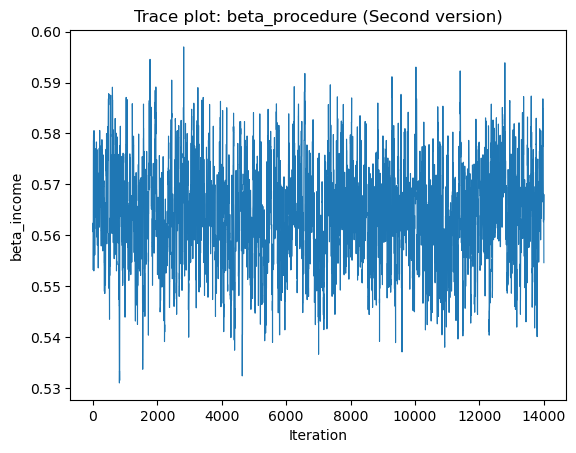

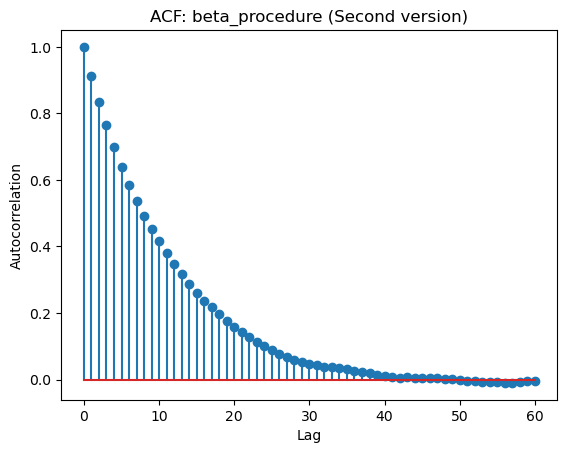

In [647]:
rng = np.random.default_rng(20)
T = 20000
scale = 0.5
chain_cc2, acc_rate_cc2 = mh_fisher_informed(beta_mle_p, T, scale, rng, y, X, tau, V_base_p)
print("Acceptance rate (Second version):", acc_rate_cc2)

burn = int(0.30 * T)
samples = chain_cc2[burn::, :]

print("\nBayesian posterior summaries (Second version)")
for j, name in enumerate(colnames):
    b = samples[:, j]
    mean = np.mean(b)
    sd = np.std(b)
    lo, hi = np.quantile(b, [0.025, 0.975])
    print(f"{name:>12s} | mean={mean: .4f} | sd={sd: .4f} | 95% CI=({lo: .4f}, {hi: .4f})")

procedure_samples = samples[:, j_procedure]

plt.figure()
plt.plot(procedure_samples, linewidth=0.8)
plt.title("Trace plot: beta_procedure (Second version)")
plt.xlabel("Iteration")
plt.ylabel("beta_income")
plt.show()

nlags = 60
r = acf(procedure_samples, nlags=nlags, fft=True)
plt.figure()
plt.stem(range(nlags + 1), r)
plt.title("ACF: beta_procedure (Second version)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()